In [79]:
import os
import shutil
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import array_to_img, img_to_array, load_img
from keras.preprocessing.image import ImageDataGenerator

In [74]:
# Bildgrößen und Pfad definieren
IMAGE_SIZE = (128, 128)
IMAGE_DIRECTORY = "use_these_images"

In [75]:
# Funktion zum Verschieben und Umbenennen von Dateien
def move_and_rename_files(src_dir, dest_dir, prefix, orig_name):
    # Sicherstellen, dass das Zielverzeichnis existiert
    os.makedirs(dest_dir, exist_ok=True)
    
    # Durch alle Dateien im Quellverzeichnis iterieren
    for i, filename in enumerate(os.listdir(src_dir)):
        # Vollständiger Pfad zur Quelldatei
        src_path = os.path.join(src_dir, filename)
        
        # Neuer Dateiname mit Präfix und Zähler
        new_filename = f"{prefix}{i}{orig_name}"
        
        # Vollständiger Pfad zur Zieldatei
        dest_path = os.path.join(dest_dir, new_filename)
        
        # Datei verschieben und umbenennen
        shutil.move(src_path, dest_path)


In [82]:
# Funktion zur Durchführung der Data Augmentation für ein einzelnes Bild
def augment_image(img, filename, orig_dir, save_dir, augmentations=5):
    # Bild laden
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    
    # Instanz der ImageDataGenerator-Klasse erstellen
    datagen = ImageDataGenerator(
        shear_range=0,
        zoom_range=[1, 1],
        width_shift_range=[0, 0],
        height_shift_range=[0, 0],
        horizontal_flip=False,
        fill_mode='nearest',
        brightness_range=[0.1, 2.5]
    )
    
    # Generierte Bilder speichern
    i = 0
    for batch in datagen.flow(x, batch_size=1, save_to_dir=save_dir, save_prefix='aug', save_format='jpg'):
        # print(batch)
        i += 1
        if i >= augmentations:
            # print(filename)
            move_and_rename_files(save_dir, orig_dir, 'aug', filename)
            break


In [88]:
# Funktion zum Einlesen der Bilder und Labels
def augment_images_from_directory(directory):
    images = []
    labels = []

    for filename in os.listdir(directory):
        if filename.endswith('.jpg'):
          # label = filename.split('_')[1].split(".")[0]
          label = filename.split("_")[4].split(".")[0]
        else:
          continue

        label = float(label)
        labels.append(label)

        img = cv2.imread(os.path.join(directory, filename))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Data Augmentation für jedes Bild im Verzeichnis durchführen
        augment_image(img_rgb, filename, directory, "img_aug", augmentations=5)

    return labels

[58.0, 50.0, 79.0, 56.0, 95.0, 93.0, 89.0, 85.0, 93.0, 96.0, 88.0, 94.0, 92.0, 110.0, 112.0, 112.0, 120.0, 128.0, 130.0, 135.0, 135.0, 135.0, 120.0, 135.0, 135.0, 135.0, 135.0, 135.0, 110.0, 100.0, 100.0, 78.0, 95.0, 67.0, 60.0, 58.0, 56.0, 54.0, 70.0, 87.0, 76.0, 94.0, 120.0, 130.0, 130.0, 135.0, 135.0, 135.0, 135.0, 135.0, 135.0, 135.0, 125.0, 90.0, 124.0, 110.0, 135.0, 135.0, 135.0, 135.0, 110.0, 100.0, 100.0, 100.0, 75.0, 54.0, 45.0, 83.0, 65.0, 84.0, 97.0, 91.0, 88.0, 92.0, 88.0, 91.0, 89.0, 94.0, 94.0, 92.0, 127.0, 130.0, 131.0, 135.0, 113.0, 120.0, 135.0, 120.0, 135.0, 135.0, 135.0, 135.0, 135.0, 130.0, 93.0, 77.0, 72.0, 78.0, 50.0, 64.0, 55.0, 57.0, 51.0, 47.0, 87.0, 60.0, 97.0, 98.0, 100.0, 130.0, 135.0, 135.0, 135.0, 131.0, 120.0, 120.0, 122.0, 121.0, 127.0, 120.0, 120.0, 135.0, 135.0, 135.0, 135.0, 111.0, 100.0, 110.0, 100.0, 80.0, 57.0, 45.0, 85.0, 96.0, 99.0, 100.0, 94.0, 129.0, 92.0, 90.0, 94.0, 94.0, 92.0, 88.0, 94.0, 128.0, 128.0, 130.0, 135.0, 128.0, 120.0, 130.0, 135.

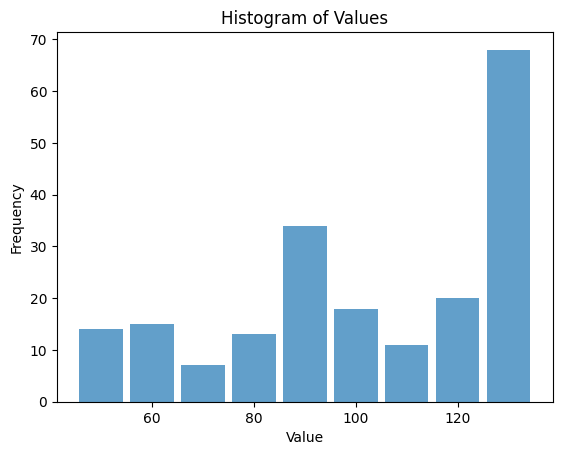

In [90]:
labels = augment_images_from_directory(IMAGE_DIRECTORY)
print (labels)
labels = np.array(labels)

# Erstelle ein Histogramm der Werte
plt.hist(labels, bins='auto', alpha=0.7, rwidth=0.85)

# Titel und Achsenbeschriftungen hinzufügen
plt.title('Histogram of Values')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Diagramm anzeigen
plt.show()